In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv("E:\python3\ml\solar-power.csv")


In [3]:

print(df.head())
print(df.describe())

df = df.dropna()
df = df.drop_duplicates()

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
        PLANT_ID      DC_POWER      AC_POWER   DAILY_YIELD   TOTAL_YIELD
count    68778.0  68778.000000  68778.000000  68778.000000  6.877800e+04
mean   4135001.0   3147.426211    307.802752   3295.968737  6.978712e+06
std          0.0   4036.457169    394.396439   3145.178309  4.162720e+05
min    4135001.0      0.000000      0.000000      0.000000  6.183645e+06
25%    4135001.0      0.000000    

C:\Users\deepa\AppData\Local\Temp\ipykernel_16584\3339686880.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])


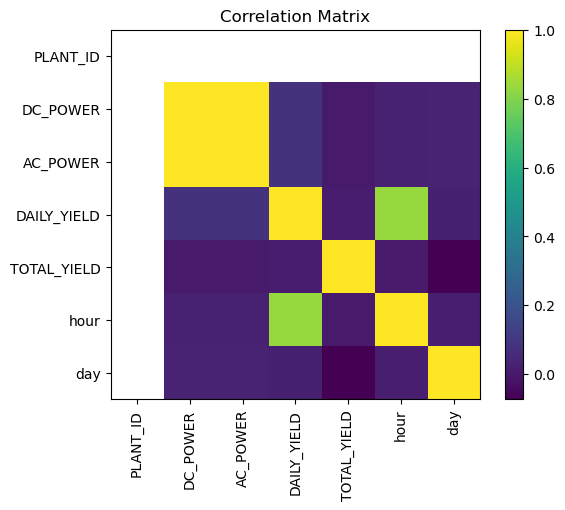

In [4]:
if 'DATE_TIME' in df.columns:
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
    df['hour'] = df['DATE_TIME'].dt.hour
    df['day'] = df['DATE_TIME'].dt.day

corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [6]:
features = [col for col in df.columns if col not in ['AC_POWER', 'DATE_TIME']]
target = 'AC_POWER'

X = df[features]
y = df[target]
X = X.select_dtypes(include=['int64', 'float64'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.9999913323633566
MAE: 0.1600866106665699


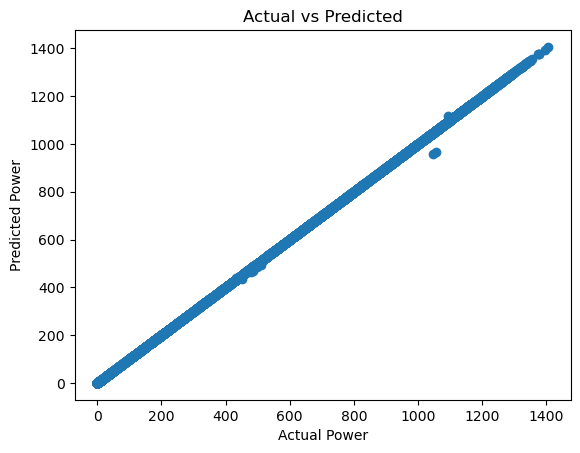

In [9]:

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted")
plt.show()

importances = model.feature_importances_
feature_names = X.columns



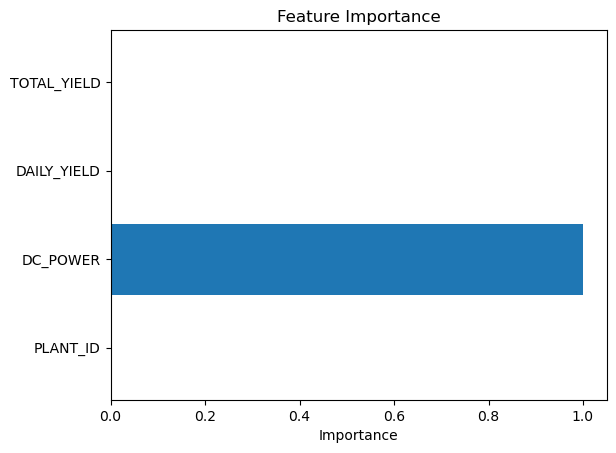

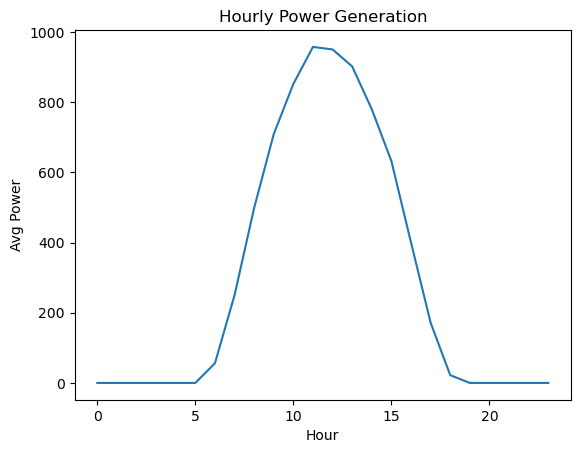

In [10]:
plt.figure()
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

if 'IRRADIATION' in df.columns:
    plt.figure()
    plt.scatter(df['IRRADIATION'], df['AC_POWER'])
    plt.xlabel("Irradiation")
    plt.ylabel("Power")
    plt.title("Irradiation vs Power")
    plt.show()

if 'AMBIENT_TEMPERATURE' in df.columns:
    plt.figure()
    plt.scatter(df['AMBIENT_TEMPERATURE'], df['AC_POWER'])
    plt.xlabel("Temperature")
    plt.ylabel("Power")
    plt.title("Temperature vs Power")
    plt.show()

if 'hour' in df.columns:
    hourly = df.groupby('hour')['AC_POWER'].mean()
    plt.figure()
    plt.plot(hourly.index, hourly.values)
    plt.xlabel("Hour")
    plt.ylabel("Avg Power")
    plt.title("Hourly Power Generation")
    plt.show()